In [1]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import seaborn as sns
from prophet.diagnostics import cross_validation, performance_metrics
import itertools

In [2]:
df = pd.read_parquet('../data/processed/preprocessed_hwes.parquet')
df.dropna(inplace = True)
df.head()

,mempool_blocks_blockSize,mempool_blocks_blockVSize,mempool_blocks_nTx,mempool_blocks_totalFees,mempool_blocks_medianFee,recommended_fee_fastestFee,recommended_fee_halfHourFee,recommended_fee_hourFee,recommended_fee_economyFee,recommended_fee_minimumFee,...,mempool_fee_histogram_bin_70_75,mempool_fee_histogram_bin_75_80,mempool_fee_histogram_bin_80_85,mempool_fee_histogram_bin_85_90,mempool_fee_histogram_bin_90_95,mempool_fee_histogram_bin_95_100,mempool_fee_histogram_bin_100_150,mempool_fee_histogram_bin_150_200,mempool_fee_histogram_bin_200_250,mempool_fee_histogram_bin_250_300
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-03-05 02:10:00,2131827.0,997874.25,1030.0,2077770.0,1.300139,2.0,2.0,2.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-05 02:15:00,1986259.0,997882.00,1915.0,2663152.0,2.000000,2.0,2.0,2.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-05 02:20:00,1814202.0,997958.25,2710.0,3423846.0,2.413300,3.0,3.0,3.0,3.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-05 02:25:00,1604116.0,997937.50,3256.0,4136741.0,3.008581,4.0,3.0,3.0,3.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-05 02:30:00,2200654.0,997987.75,1015.0,1890732.0,1.362632,2.0,2.0,2.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
y = df["recommended_fee_fastestFee"]
X = df.drop(columns = "recommended_fee_fastestFee")
X = X.reset_index()
X = X.drop(columns = "timestamp")

# last 24h as test
split_index = len(X) - 288

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [4]:
df_prophet = y_train.reset_index()
df_prophet = df_prophet.rename(columns={
    'timestamp': 'ds',
    'recommended_fee_fastestFee': 'y'
})
df_prophet.head()

,ds,y
0,2025-03-05 02:10:00,2.0
1,2025-03-05 02:15:00,2.0
2,2025-03-05 02:20:00,3.0
3,2025-03-05 02:25:00,4.0
4,2025-03-05 02:30:00,2.0


In [5]:
model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=False
)
model.add_seasonality(name='hourly', period=1/24, fourier_order=5) # 每小时重复（注意 period 是 1/24）
model.add_seasonality(name='hourly', period=1, fourier_order=10)  # 每小时周期
model.add_seasonality(name='daily', period=24, fourier_order=5)  # 每日周期

In [6]:
param_grid = {  
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [1.0, 10.0, 20.0],
    'seasonality_mode': ['additive', 'multiplicative']
}

In [7]:
# 创建参数组合
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]

results = []  # 存放每组评估结果

for params in all_params:
    m = Prophet(
        daily_seasonality=False,
        weekly_seasonality=False,
        **params
    )
    m.add_seasonality(name='hourly', period=1/24, fourier_order=6)
    m.add_seasonality(name='daily', period=1, fourier_order=8)
    m.add_seasonality(name='weekly', period=7, fourier_order=4)
    
    m.fit(df_prophet)
    df_cv = cross_validation(m, initial='7 days', period='1 day', horizon='1 day', parallel="processes")
    df_p = performance_metrics(df_cv)
    
    results.append((params, df_p['rmse'].mean()))
print("Done")

20:07:28 - cmdstanpy - INFO - Chain [1] start processing
20:07:28 - cmdstanpy - INFO - Chain [1] done processing
20:07:29 - cmdstanpy - INFO - Chain [1] start processing
20:07:29 - cmdstanpy - INFO - Chain [1] start processing
20:07:30 - cmdstanpy - INFO - Chain [1] start processing
20:07:30 - cmdstanpy - INFO - Chain [1] done processing
20:07:30 - cmdstanpy - INFO - Chain [1] start processing
20:07:30 - cmdstanpy - INFO - Chain [1] start processing
20:07:30 - cmdstanpy - INFO - Chain [1] start processing
20:07:30 - cmdstanpy - INFO - Chain [1] start processing
20:07:30 - cmdstanpy - INFO - Chain [1] done processing
20:07:30 - cmdstanpy - INFO - Chain [1] start processing
20:07:30 - cmdstanpy - INFO - Chain [1] done processing
20:07:30 - cmdstanpy - INFO - Chain [1] start processing
20:07:30 - cmdstanpy - INFO - Chain [1] done processing
20:07:30 - cmdstanpy - INFO - Chain [1] start processing
20:07:30 - cmdstanpy - INFO - Chain [1] done processing
20:07:30 - cmdstanpy - INFO - Chain [

Done


In [8]:
best_params = sorted(results, key=lambda x: x[1])[0]
print(f"最优参数组合：{best_params[0]}\n对应RMSE：{best_params[1]:.4f}")

最优参数组合：{'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'additive'}
对应RMSE：2.4788


In [9]:
model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=False,
    changepoint_prior_scale = 0.001,
    seasonality_prior_scale=10.0,
    seasonality_mode='additive'
)
model.add_seasonality(name='hourly', period=1/24, fourier_order=5) # 每小时重复（注意 period 是 1/24）
model.add_seasonality(name='hourly', period=1, fourier_order=10)  # 每小时周期
model.add_seasonality(name='daily', period=24, fourier_order=5)  # 每日周期

In [10]:
model.fit(df_prophet)

20:14:32 - cmdstanpy - INFO - Chain [1] start processing
20:14:32 - cmdstanpy - INFO - Chain [1] done processing


In [11]:
future = model.make_future_dataframe(periods=288, freq='5min')

In [12]:
forecast = model.predict(future)

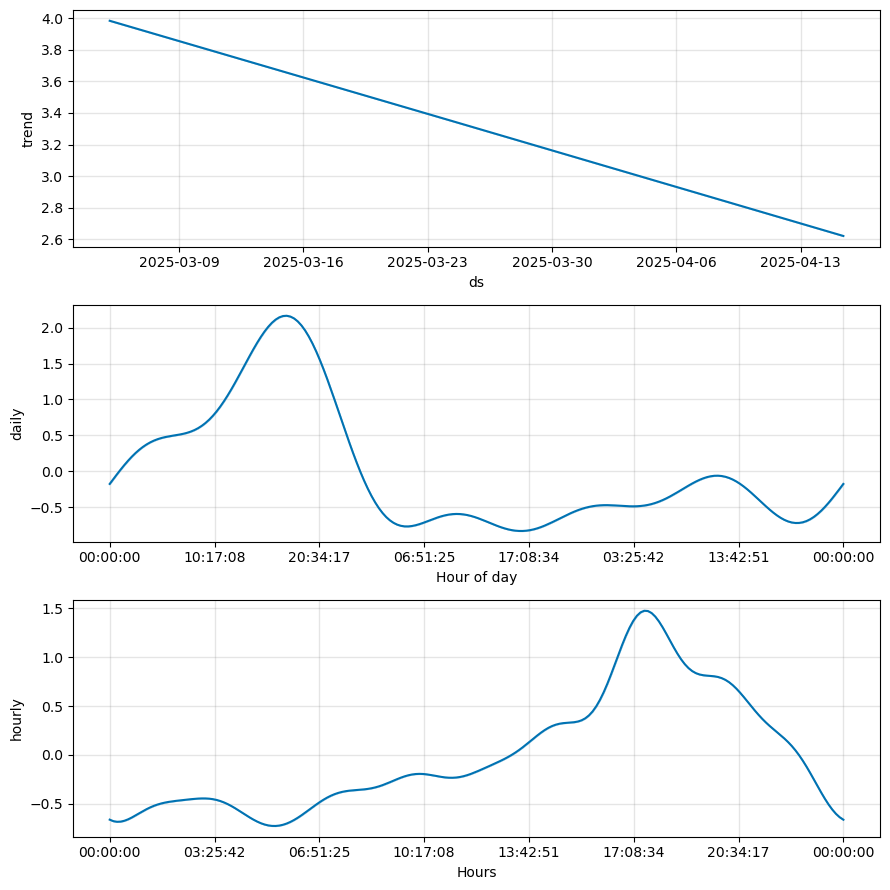

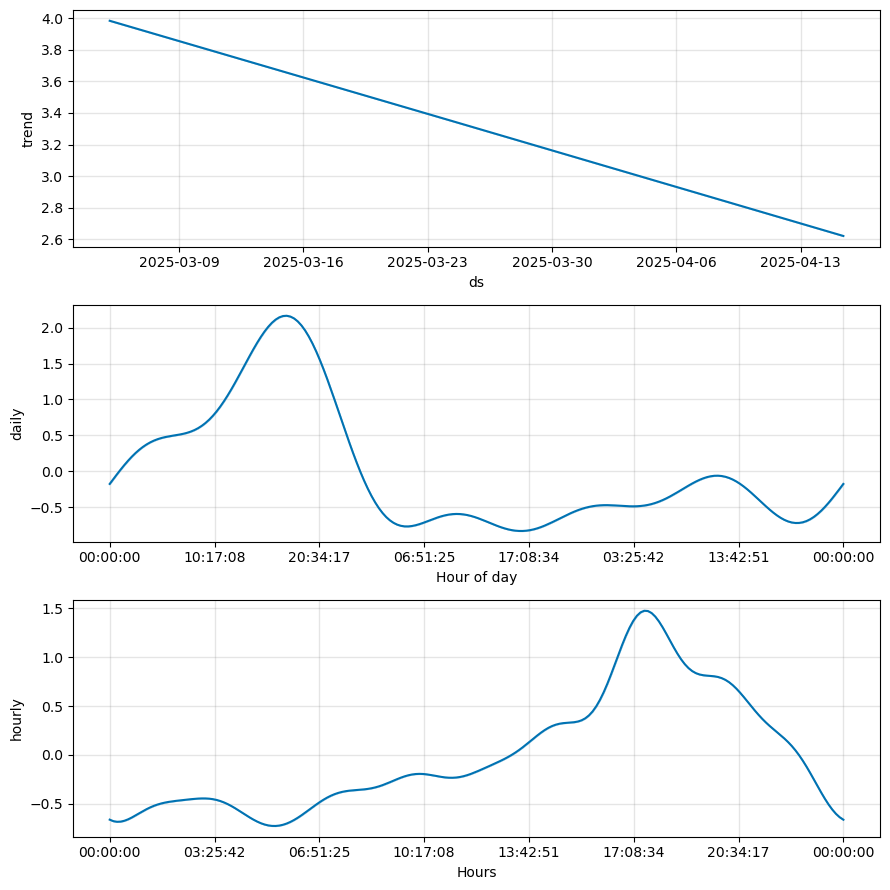

In [13]:
model.plot_components(forecast)

In [14]:
forecast.index = y.index

In [15]:
y_pred = forecast.iloc[-288:]
y_pred = y_pred["yhat"]

In [16]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

MAE: 1.3613
RMSE: 1.6165
MAPE: 0.8498


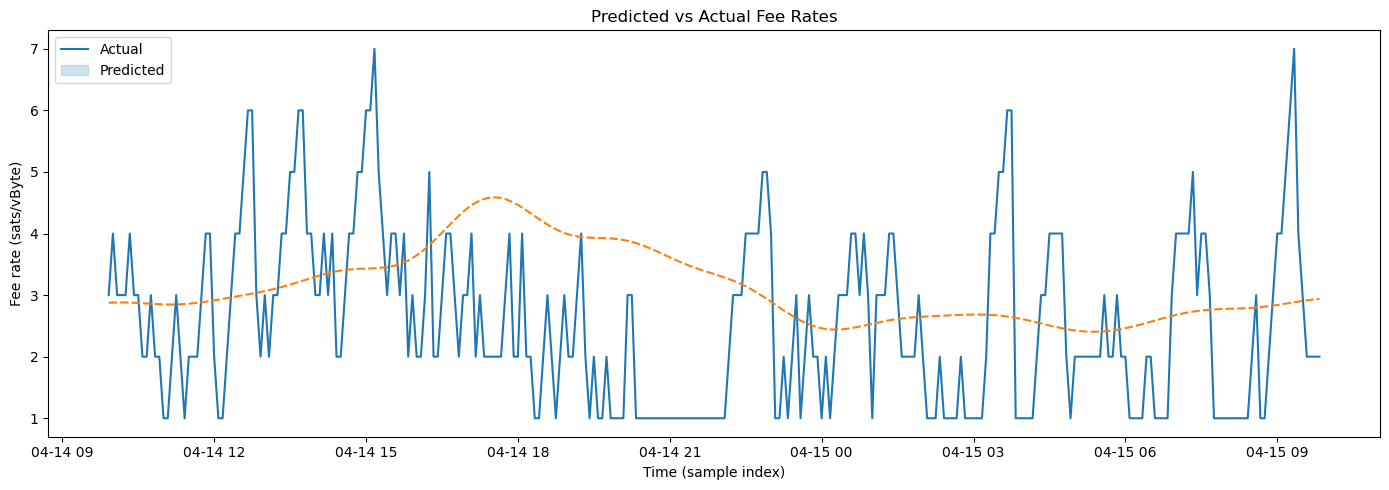

In [17]:
result_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
}, index=y_test.index)

plt.figure(figsize=(14, 5))
sns.lineplot(data=result_df)
plt.title('Predicted vs Actual Fee Rates')
plt.xlabel('Time (sample index)')
plt.ylabel('Fee rate (sats/vByte)')
plt.legend(['Actual', 'Predicted'])
plt.tight_layout()
plt.show()

In [18]:
df_cv = cross_validation(model, initial='7 days', period='1 day', horizon='1 day')
performance_metrics(df_cv)

Seasonality has period of 24 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/33 [00:00<?, ?it/s]

20:14:59 - cmdstanpy - INFO - Chain [1] start processing
20:14:59 - cmdstanpy - INFO - Chain [1] done processing
20:14:59 - cmdstanpy - INFO - Chain [1] start processing
20:14:59 - cmdstanpy - INFO - Chain [1] done processing
20:14:59 - cmdstanpy - INFO - Chain [1] start processing
20:14:59 - cmdstanpy - INFO - Chain [1] done processing
20:15:00 - cmdstanpy - INFO - Chain [1] start processing
20:15:00 - cmdstanpy - INFO - Chain [1] done processing
20:15:00 - cmdstanpy - INFO - Chain [1] start processing
20:15:00 - cmdstanpy - INFO - Chain [1] done processing
20:15:00 - cmdstanpy - INFO - Chain [1] start processing
20:15:00 - cmdstanpy - INFO - Chain [1] done processing
20:15:00 - cmdstanpy - INFO - Chain [1] start processing
20:15:00 - cmdstanpy - INFO - Chain [1] done processing
20:15:00 - cmdstanpy - INFO - Chain [1] start processing
20:15:00 - cmdstanpy - INFO - Chain [1] done processing
20:15:01 - cmdstanpy - INFO - Chain [1] start processing
20:15:01 - cmdstanpy - INFO - Chain [1]

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,0 days 02:25:00,3.066824,1.751235,1.378144,0.604249,0.417993,0.464227,0.856459
1,0 days 02:30:00,3.026561,1.739701,1.374296,0.602224,0.418242,0.463296,0.856459
2,0 days 02:35:00,2.971416,1.723779,1.367754,0.601036,0.418520,0.462454,0.857129
3,0 days 02:40:00,2.920532,1.708957,1.356950,0.597912,0.417099,0.460231,0.862392
4,0 days 02:45:00,2.875650,1.695774,1.347090,0.592611,0.415865,0.457170,0.862998
...,...,...,...,...,...,...,...,...
255,0 days 23:40:00,3.408541,1.846223,1.255782,0.531625,0.405446,0.448571,0.910367
256,0 days 23:45:00,3.399735,1.843837,1.250391,0.530546,0.404528,0.445749,0.909091
257,0 days 23:50:00,3.421645,1.849769,1.254955,0.532960,0.405729,0.446125,0.908262
258,0 days 23:55:00,3.410890,1.846860,1.254276,0.531273,0.405461,0.444634,0.910144
